This project develops a multi-asset investment strategy that combines momentum-based signals with constrained mean-variance optimization to construct portfolios in a realistic, out-of-sample setting.

Traditional portfolio optimization relies on unstable estimates of expected returns, often leading to unreliable allocations. To address this, the model separates alpha generation from capital allocation, using momentum to identify attractive assets and optimization to control risk and diversification.

The strategy is implemented in a rolling framework with monthly rebalancing and daily return tracking, incorporating transaction costs and evaluated across both performance and downside risk metrics.

In [5]:
# ==============================
# IMPORTS
# ==============================
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from scipy.optimize import minimize

plt.style.use("seaborn-v0_8")

In [6]:
tickers = [

# Technology
"AAPL","MSFT","NVDA","GOOGL",

# Financials
"JPM","BAC","GS",

# Energy
"XOM","CVX",

# Healthcare
"UNH","MRK",

# Consumer
"AMZN","HD",

# Industrials
"CAT","GE",

# Diversifiers
"GLD","TLT","VNQ",

"SPY"

]

benchmark = "SPY"


In [9]:
# ===============================
# Data Collection
# ===============================

start = "2015-01-01"
end = "2024-01-01"

data = yf.download(tickers, start=start, end=end)["Close"]
returns = data.pct_change().dropna()


[*********************100%***********************]  19 of 19 completed


In [11]:
# ==============================
# PARAMETERS
# ==============================
risk_free = 0.02
num_assets = len(tickers)

window = 252                # 1 year
rebalance_step = 21         # monthly
momentum_lookback = 252

bounds = tuple((0, 0.4) for _ in range(num_assets))
constraints = {'type': 'eq', 'fun': lambda x: np.sum(x) - 1}

In [13]:
# ==============================
# FUNCTIONS
# ==============================
def portfolio_performance(weights, mean_returns, cov_matrix):
    ret = np.dot(weights, mean_returns)
    vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    return ret, vol


def max_drawdown(series):
    cum = (1 + series).cumprod()
    peak = cum.cummax()
    return ((cum - peak) / peak).min()


def portfolio_summary(name, series):
    log_ret = np.log1p(series)

    ann_return = np.exp(log_ret.mean() * 252) - 1
    ann_vol = series.std() * np.sqrt(252)

    return {
        "Strategy": name,
        "Return": ann_return,
        "Volatility": ann_vol,
        "Sharpe": (ann_return - risk_free) / ann_vol,
        "Max Drawdown": max_drawdown(series)
    }

In [15]:
# ==============================
# ROLLING STRATEGY
# ==============================
rolling_returns = []
rolling_dates = []
weights_history = []

prev_weights = np.array([1/num_assets]*num_assets)

for i in range(window, len(returns), rebalance_step):

    train = returns.iloc[i-window:i]
    mean_r = train.mean() * 252
    cov_r = train.cov() * 252

    # stabilize covariance
    cov_r += np.eye(len(cov_r)) * 1e-6

    # --------------------------
    # MOMENTUM SIGNAL
    # --------------------------
    price_window = data.iloc[i-momentum_lookback:i]

    momentum = price_window.pct_change().mean() * 252
    momentum = momentum.clip(lower=0)

    if momentum.sum() == 0:
        momentum_weights = np.array([1/num_assets]*num_assets)
    else:
        momentum_weights = momentum / momentum.sum()

    # --------------------------
    # OPTIMIZATION
    # --------------------------
    def objective(w):
        ret, vol = portfolio_performance(w, mean_r, cov_r)

        if not np.isfinite(ret) or not np.isfinite(vol) or vol <= 1e-8:
            return 1e6

        turnover = np.sum(np.abs(w - prev_weights))
        cost = 0.001 * turnover

        return -(ret - risk_free) / vol + cost

    res = minimize(
        objective,
        prev_weights,
        method='SLSQP',
        bounds=bounds,
        constraints=constraints,
        options={'maxiter': 50}
    )

    if res.success and np.all(np.isfinite(res.x)):
        opt_weights = res.x
    else:
        opt_weights = prev_weights.copy()

    # --------------------------
    # FINAL WEIGHTS
    # --------------------------
    final_weights = 0.5 * opt_weights + 0.5 * momentum_weights
    final_weights /= final_weights.sum()

    weights_history.append(final_weights)

    # --------------------------
    # APPLY WEIGHTS DAILY
    # --------------------------
    for j in range(i, min(i + rebalance_step, len(returns))):
        daily_ret = np.dot(final_weights, returns.iloc[j])
        rolling_returns.append(daily_ret)
        rolling_dates.append(returns.index[j])

    prev_weights = final_weights

rolling_returns = pd.Series(rolling_returns, index=rolling_dates)
rolling_cum = (1 + rolling_returns).cumprod()

In [16]:
# ==============================
# BASELINES
# ==============================
equal_weights = np.array([1/num_assets]*num_assets)
equal_returns = returns.dot(equal_weights)

benchmark_returns = returns[benchmark]

aligned_equal = equal_returns.loc[rolling_returns.index]
aligned_benchmark = benchmark_returns.loc[rolling_returns.index]

In [19]:
# ==============================
# PERFORMANCE SUMMARY
# ==============================
summary = pd.DataFrame([
    portfolio_summary("Momentum + Optimization", rolling_returns),
    portfolio_summary("Equal Weight", aligned_equal),
    portfolio_summary("Benchmark (SPY)", aligned_benchmark)
])

print(summary)

                  Strategy    Return  Volatility    Sharpe  Max Drawdown
0  Momentum + Optimization  0.212451    0.184376  1.043800     -0.219641
1             Equal Weight  0.192440    0.184011  0.937120     -0.325029
2          Benchmark (SPY)  0.133722    0.183967  0.618167     -0.337173


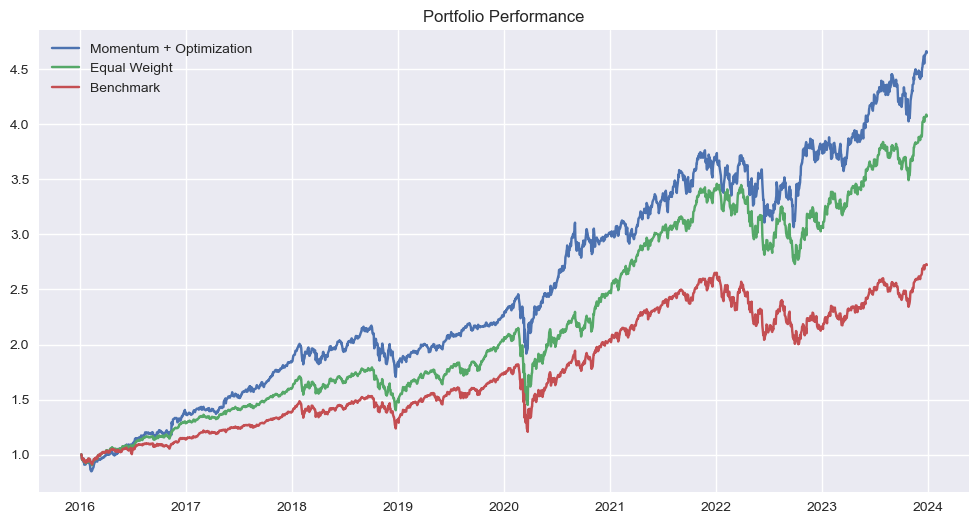

In [21]:
# ==============================
# PERFORMANCE PLOT
# ==============================
plt.figure(figsize=(12,6))

plt.plot(rolling_cum, label="Momentum + Optimization")
plt.plot((1+aligned_equal).cumprod(), label="Equal Weight")
plt.plot((1+aligned_benchmark).cumprod(), label="Benchmark")

plt.legend()
plt.title("Portfolio Performance")
plt.show()

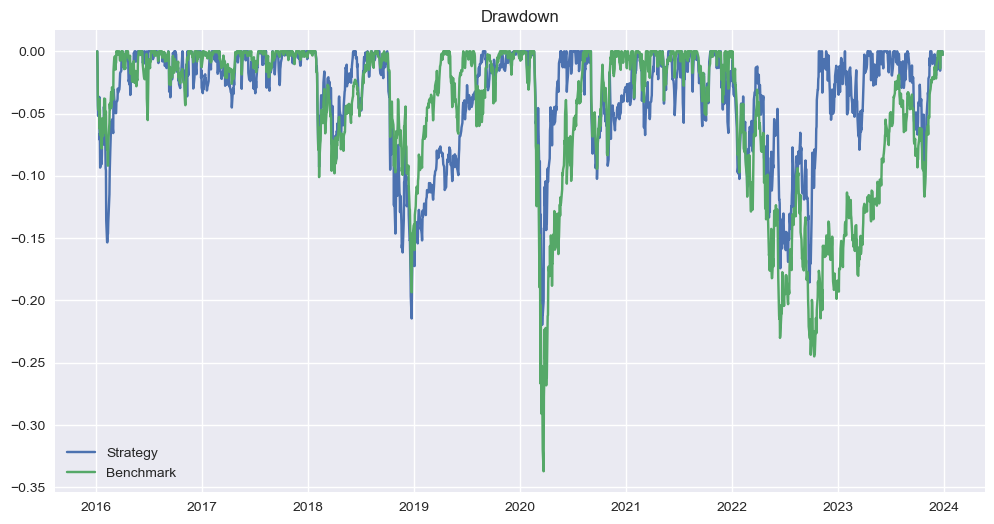

In [23]:
# ==============================
# DRAWDOWN
# ==============================
def compute_drawdown(series):
    cum = (1 + series).cumprod()
    peak = cum.cummax()
    return (cum - peak) / peak

strategy_dd = compute_drawdown(rolling_returns)
benchmark_dd = compute_drawdown(aligned_benchmark)

plt.figure(figsize=(12,6))
plt.plot(strategy_dd, label="Strategy")
plt.plot(benchmark_dd, label="Benchmark")
plt.legend()
plt.title("Drawdown")
plt.show()

In [25]:
# ==============================
# RISK CONTRIBUTION
# ==============================
def risk_contribution(weights, cov_matrix):
    port_var = np.dot(weights.T, np.dot(cov_matrix, weights))
    marginal = np.dot(cov_matrix, weights)
    return weights * marginal / port_var

last_cov = returns.iloc[-window:].cov() * 252
last_weights = weights_history[-1]

rc = risk_contribution(last_weights, last_cov)

rc_df = pd.DataFrame({
    "Asset": tickers,
    "Weight": last_weights,
    "Risk Contribution": rc
})

print(rc_df)

        Asset        Weight  Risk Contribution
Ticker                                        
AAPL     AAPL  3.599800e-02       2.435528e-02
AMZN     MSFT  7.161397e-02       7.998267e-02
BAC      NVDA  3.180996e-16       1.490318e-16
CAT     GOOGL  1.788490e-02       9.009605e-03
CVX       JPM  1.283485e-16       1.131167e-17
GE        BAC  2.709608e-01       2.454384e-01
GLD        GS  2.005522e-01       1.749845e-02
GOOGL     XOM  3.788046e-02       3.592546e-02
GS        CVX  3.436388e-16       1.613999e-16
HD        UNH  7.217265e-03       3.500887e-03
JPM       MRK  2.764638e-02       1.233608e-02
MRK      AMZN  1.124627e-03      -1.088514e-05
MSFT       HD  6.192070e-02       5.641423e-02
NVDA      CAT  2.148895e-01       5.021018e-01
SPY        GE  1.860940e-02       1.069344e-02
TLT       GLD  6.025670e-17       9.510554e-18
UNH       TLT  2.876409e-02       6.167785e-04
VNQ       VNQ  4.514332e-03       2.109516e-03
XOM       SPY  4.234422e-04       2.827213e-05


In [27]:
# ==============================
# BETA
# ==============================
aligned_strategy = rolling_returns
aligned_market = aligned_benchmark

covariance = np.cov(aligned_strategy, aligned_market)[0][1]
market_var = np.var(aligned_market)

beta = covariance / market_var

print("Portfolio Beta:", beta)

Portfolio Beta: 0.7745139250370194


Correlation with Benchmark (SPY): 0.7724143138418496


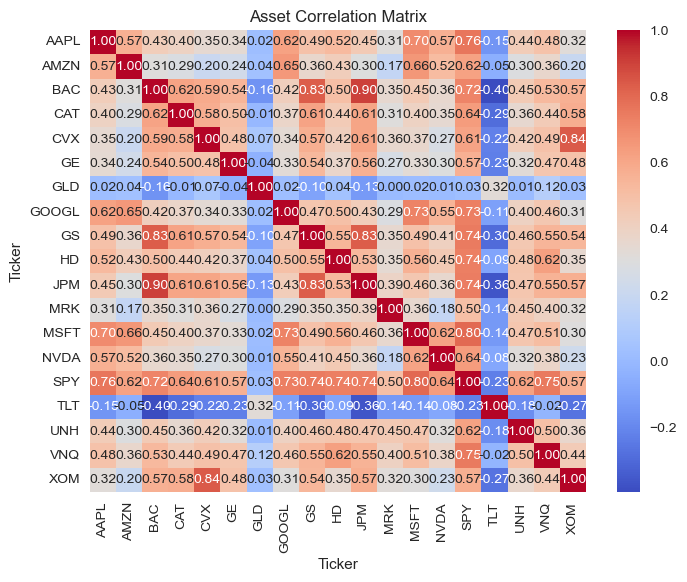

In [29]:
# ==============================
# CORRELATION ANALYSIS
# ==============================

# Strategy vs Benchmark
strategy_corr = rolling_returns.corr(aligned_benchmark)
print("Correlation with Benchmark (SPY):", strategy_corr)

# Asset correlation matrix
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(returns.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Asset Correlation Matrix")
plt.show()

In [31]:
# ==============================
# MOMENTUM SNAPSHOT
# ==============================
latest_momentum = (data.iloc[-1] / data.iloc[-252] - 1)

momentum_df = pd.DataFrame({
    "Asset": tickers,
    "Momentum": latest_momentum
}).sort_values(by="Momentum", ascending=False)

print(momentum_df)

        Asset  Momentum
Ticker                 
NVDA      CAT  2.392725
GE        BAC  0.958059
AMZN     MSFT  0.804942
GOOGL     XOM  0.579310
MSFT       HD  0.574102
AAPL     AAPL  0.493759
JPM       MRK  0.314896
SPY        GE  0.258434
CAT     GOOGL  0.256132
GS        CVX  0.158887
GLD        GS  0.132188
HD        UNH  0.111680
VNQ       VNQ  0.110440
BAC      NVDA  0.047627
TLT       GLD  0.016247
MRK      AMZN  0.011283
UNH       TLT  0.008523
XOM       SPY -0.053173
CVX       JPM -0.130660


In [37]:
# ==============================
# PERFORMANCE COMPARISON
# ==============================

comparison = pd.DataFrame({
    "Strategy": portfolio_summary("Strategy", rolling_returns),
    "Benchmark": portfolio_summary("Benchmark", aligned_benchmark),
    "Equal Weight": portfolio_summary("Equal", aligned_equal)
}).T

print(comparison)

# % Improvement vs Benchmark
improvement = pd.DataFrame({
    "Metric": ["Return", "Sharpe", "Max Drawdown"],
    "Improvement vs Benchmark": [
        comparison.loc["Strategy", "Return"] - comparison.loc["Benchmark", "Return"],
        comparison.loc["Strategy", "Sharpe"] - comparison.loc["Benchmark", "Sharpe"],
        abs(comparison.loc["Benchmark", "Max Drawdown"] - comparison.loc["Strategy", "Max Drawdown"])
    ]
})

print("\nImprovement vs Benchmark:")
print(improvement)

               Strategy    Return Volatility    Sharpe Max Drawdown
Strategy       Strategy  0.212451   0.184376    1.0438    -0.219641
Benchmark     Benchmark  0.133722   0.183967  0.618167    -0.337173
Equal Weight      Equal   0.19244   0.184011   0.93712    -0.325029

Improvement vs Benchmark:
         Metric  Improvement vs Benchmark
0        Return                  0.078729
1        Sharpe                  0.425633
2  Max Drawdown                  0.117531


## Summary

The  framework demonstrates how combining simple, economically grounded signals with disciplined portfolio construction can produce more robust investment strategies than relying on optimization alone.

By integrating momentum-driven allocation with risk-aware optimization, the model achieves improved risk-adjusted performance while maintaining controlled drawdowns and meaningful diversification relative to the benchmark.

The strategy improves risk-adjusted performance relative to the benchmark, achieving a higher Sharpe ratio (~1.04 vs 0.62) while maintaining similar volatility and reducing maximum drawdown from ~34% to ~22%.
